In [2]:
from load_sim_data import *
from load_shp import *
from sim_eval_pkg import *

Updated on 2026-03-04


In [3]:
alpha = ['a','b','c','d','e','f']
regions = [
    (-130, -60, 15, 60, 'North America'),
    (-20, 45, 30, 75, 'Europe'),
    (-85, -30, -56, 15, 'South America'),
    (90, 150, 5, 50, 'East Asia/Southeast Asia'),
    (-20, 60, -40, 35, 'Africa'),
    (110, 180, -50, 10, 'Australia/Oceania')
]
df_summer = build_global_summer_df(station_df_JJA_path, station_df_DJF_path)
df = df_summer.dropna(subset=['lat', 'lon'])
df['lon_adj'] = df['lon'].apply(lambda x: x if x <= 180 else x - 360)

___

### Figure S10

___

In [4]:
def plot_station_daily_improvement(metric='rmse', title_suffix='2010-2019 Summer', size_factor=150, alpha_sig=0.05):
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3)
    ax_summary = fig.add_subplot(gs[1, 1], projection=ccrs.Robinson())
    ax_summary.set_global()
    ax_summary.coastlines(linewidth=0.5)
    ax_summary.add_feature(cfeature.OCEAN, color='whitesmoke')
    ax_summary.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)

    subplot_positions = [(0, 0), (0, 1), (0, 2), (2, 0), (2, 1), (2, 2)]
    total_valid, total_improved = 0, 0
    total_sig_improved, total_sig_degraded = 0, 0
    total_both, total_temp_only, total_rh_only = 0, 0, 0
    base_size = 50 
    indices=list('abcdef')
    
    for i, (lon_min, lon_max, lat_min, lat_max, name) in enumerate(regions):
        row, col = subplot_positions[i]
        ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.OCEAN, color='whitesmoke')
        ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)

        region_data = df[(df['lon_adj'] >= lon_min) & (df['lon_adj'] <= lon_max) &
                         (df['lat'] >= lat_min) & (df['lat'] <= lat_max)]

        valid_stations = region_data[region_data['pos_r2'] == True]
        valid_stations = valid_stations[~valid_stations['station'].isin(['U_SanJose', 'U_Springdale', 'U_KentTown'])] # integer values only

        region_valid = len(valid_stations)
        total_valid += region_valid

        if metric == 'r2':
            improved = valid_stations['r2_improved_daily']
            temp = valid_stations['temp_r2_improved_daily']
            rh = valid_stations['rh_r2_improved_daily']
            not_improved = ~valid_stations['r2_improved_daily']

            sig_temp = pd.Series(False, index=valid_stations.index)
            sig_rh = pd.Series(False, index=valid_stations.index)

        elif metric == 'rmse':
            improved = valid_stations['rmse_improved_daily']
            temp = valid_stations['temp_rmse_improved_daily']
            rh = valid_stations['rh_rmse_improved_daily']
            not_improved = ~valid_stations['rmse_improved_daily']

            sig_temp = valid_stations['sig_wilc_temp_sq']
            sig_rh = valid_stations['sig_wilc_rh_sq']
        elif metric == 'ks':
            improved = valid_stations['ks_improved_daily']
            temp = valid_stations['temp_ks_improved_daily']
            rh = valid_stations['rh_ks_improved_daily']
            not_improved = ~valid_stations['ks_improved_daily']
            
            sig_temp = pd.Series(False, index=valid_stations.index)
            sig_rh = pd.Series(False, index=valid_stations.index)
        else:
            improved = valid_stations['everything_improved_daily']
            temp = valid_stations['temp_both_improved_daily']
            rh = valid_stations['rh_both_improved_daily']
            not_improved = ~valid_stations['both_improved_daily']

            sig_temp = pd.Series(False, index=valid_stations.index)
            sig_rh = pd.Series(False, index=valid_stations.index)

        region_improved = improved.sum()
        total_improved += region_improved
        sig_improved_mask = (sig_temp | sig_rh) & improved
        region_sig_improved = int(sig_improved_mask.sum())
        total_sig_improved += region_sig_improved

        both = valid_stations[improved & temp & rh]
        temp_only = valid_stations[temp & ~valid_stations.index.isin(both.index)]
        rh_only = valid_stations[rh & ~valid_stations.index.isin(both.index)]
        not_improved_stations = valid_stations[not_improved]

        total_both += len(both)
        total_temp_only += len(temp_only)
        total_rh_only += len(rh_only)

        def sizes_for(subset, subset_name):
            if subset.empty:
                return None
            if metric == 'r2':
                return np.full(len(subset), base_size)

            if subset_name == 'both':
                is_sig = sig_temp.loc[subset.index] & sig_rh.loc[subset.index]
            elif subset_name == 'temp_only':
                is_sig = sig_temp.loc[subset.index] & ~sig_rh.loc[subset.index]
            elif subset_name == 'rh_only':
                is_sig = sig_rh.loc[subset.index] & ~sig_temp.loc[subset.index]
            else:  # not_improved
                is_sig = pd.Series(False, index=subset.index)
            return np.where(is_sig.values, size_factor, base_size)

        for subset, color, subset_name in zip(
            [both, temp_only, rh_only, not_improved_stations],
            ['green', 'red', 'blue', 'yellow'],
            ['both', 'temp_only', 'rh_only', 'not_improved']
        ):
            s_vals = sizes_for(subset, subset_name)
            ax.scatter(subset['lon_adj'], subset['lat'],
                       s=base_size if s_vals is None else s_vals,
                       marker='*' if color != 'yellow' else 'o',
                       facecolor=color, edgecolor='black', alpha=0.7, linewidth=0.8, zorder=100)

        improvement_ratio = (region_improved / region_valid * 100) if region_valid else 0
        sig_improvement_ratio = (region_sig_improved / region_improved * 100) if region_improved else 0
        if metric == 'rmse':
            stats_text = f'{region_valid} stations\n{improvement_ratio:.1f}% {metric.upper()} reduced\n{sig_improvement_ratio:.1f}% of them are significant'
        elif metric == 'ks':
            stats_text = f'{region_valid} stations\n{improvement_ratio:.1f}% {metric.upper()} reduced'
        elif metric == 'r2':
            stats_text = f'{region_valid} stations\n{improvement_ratio:.1f}% {metric.upper()} increased'
            

        ax.text(0.02, 0.02, stats_text, transform=ax.transAxes,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round'), fontsize=10)
        ax.set_title(f'{alpha[i]}. {name}', fontsize=14)
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle=':')
        gl.top_labels = False
        gl.right_labels = False

        ax_summary.plot([lon_min, lon_max, lon_max, lon_min, lon_min],
                        [lat_min, lat_min, lat_max, lat_max, lat_min],
                        transform=ccrs.PlateCarree(), color='black', linewidth=1)
        ax_summary.text((lon_min + lon_max)/2, (lat_min + lat_max)/2, indices[i],
                        transform=ccrs.PlateCarree(), fontsize=12,
                        ha='center', va='center',
                        bbox=dict(facecolor='white', alpha=0.7))

    ax_summary.set_title(f'Global Overview - {title_suffix}', fontsize=16)
    global_ratio = (total_improved / total_valid * 100) if total_valid else 0
    improved_direction = 'increased' if metric == 'r2' else 'reduced'
    global_stats = (f'Total valid stations: {total_valid}\n'
                    f'Total {metric.upper()} {improved_direction}: {total_improved}\n'
                    f'Global improvement: {global_ratio:.1f}%')

    ax_summary.text(0.01, 0.02, global_stats, transform=ax_summary.transAxes,
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round'), fontsize=12)

    improved_value = 'Higher' if metric == 'r2' else 'Lower'
    legend_elements = [
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='green', markersize=12,
                   markeredgecolor='black', label=f'{improved_value} {metric.upper()} in Temp & RH'),
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='red', markersize=12,
                   markeredgecolor='black', label=f'{improved_value} {metric.upper()} in Temp'),
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='blue', markersize=12,
                   markeredgecolor='black', label=f'{improved_value} {metric.upper()} in RH'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=11,
                   markeredgecolor='black', label=f'{improved_value} {metric.upper()}')
    ]
    if metric == 'rmse':
        legend_elements.append(
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='gray', markeredgecolor='black',
                   markersize=18, label='Significant'))
        
    legend_ax1 = fig.add_axes([0.2, 0.55, 0.2, 0.06])
    legend_ax1.axis('off')
    legend_ax1.legend(handles=legend_elements, loc='center', title='Station Type', fontsize=12,
                      title_fontsize=12, frameon=True, framealpha=0.9)

    plt.tight_layout()
    plt.subplots_adjust(top=0.94, hspace=0.15, wspace=0.3, bottom=0.08)
    plt.show()
    print(total_both,total_temp_only,total_rh_only)
    return fig

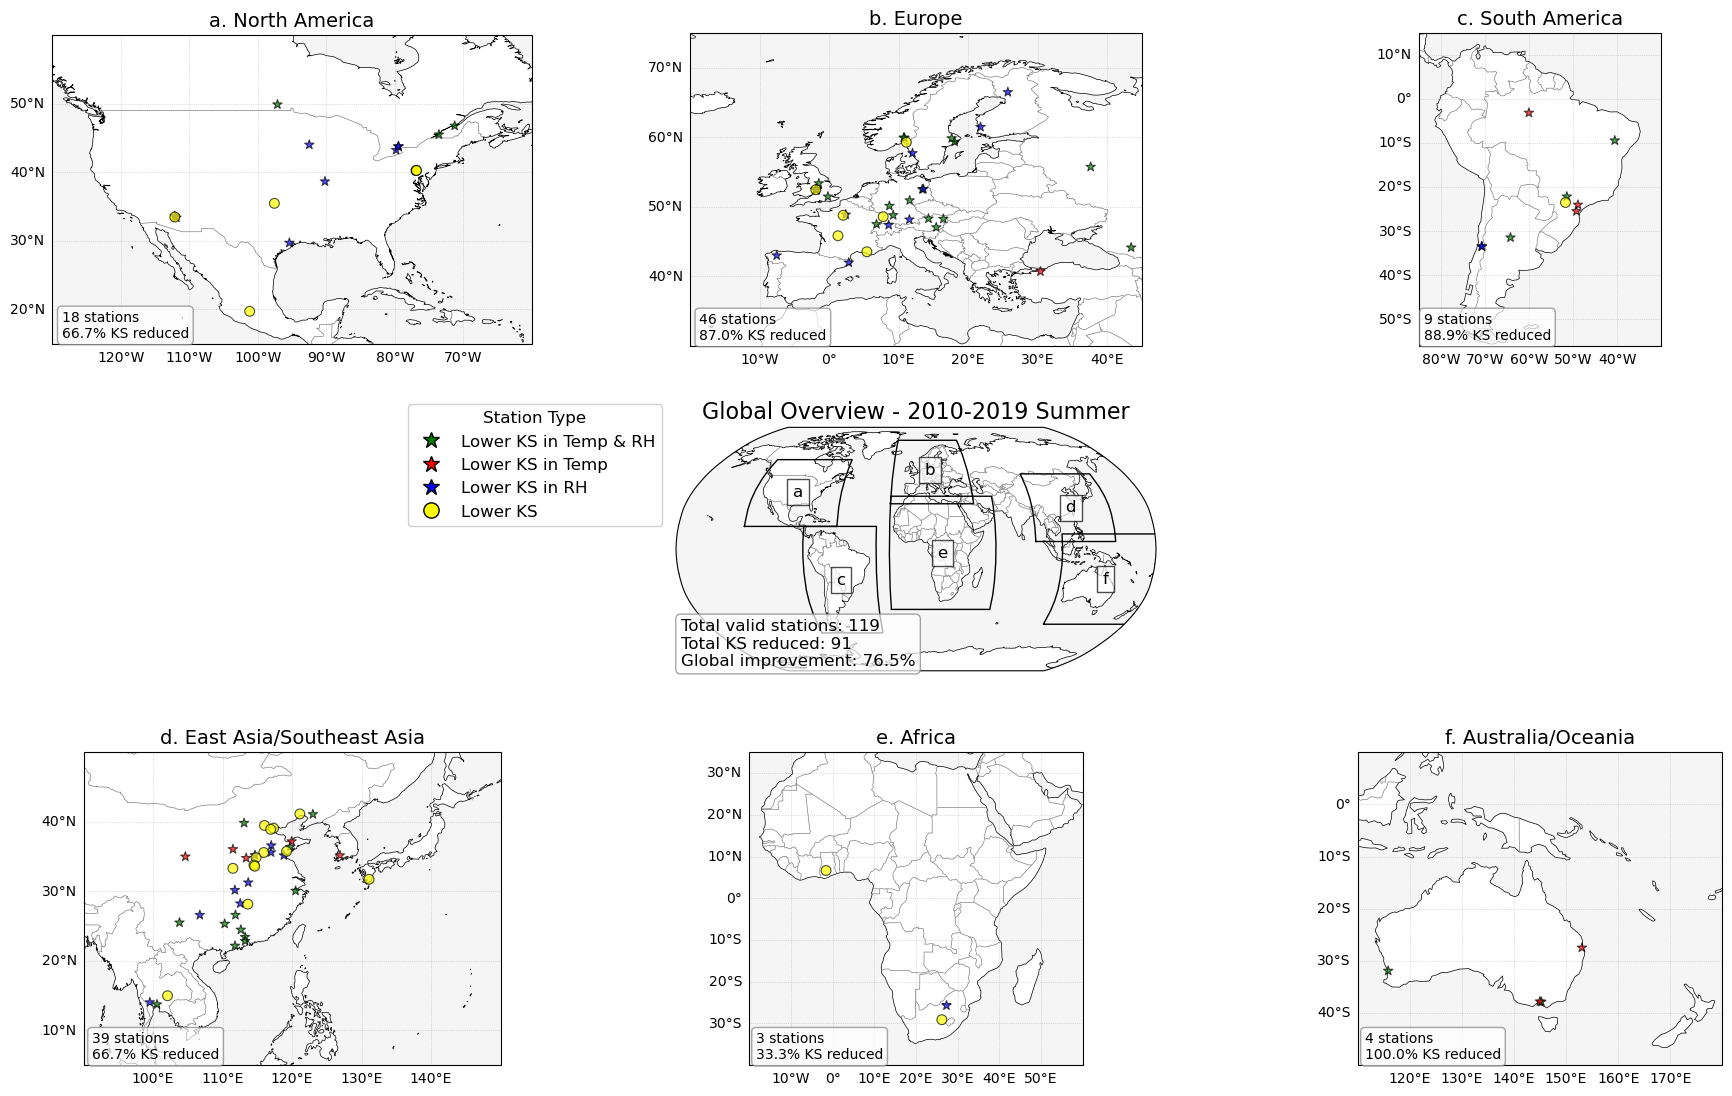

36 13 42


In [5]:
fig=plot_station_daily_improvement(metric='ks', title_suffix='2010-2019 Summer', size_factor=150)